# Inventory Trajectory

This notebook loads a saved daily simulation snapshot CSV and plots the inventory trajectory over time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
snapshot_csv_path = Path("../../data/simulation/m5_foods_3_080_ca_1/val_daily_snapshots.csv")
snapshot_csv_path

PosixPath('../../data/simulation/m5_foods_3_080_ca_1/val_daily_snapshots.csv')

In [3]:
snapshots = pd.read_csv(snapshot_csv_path)
snapshots["date"] = pd.to_datetime(snapshots["date"])
snapshots = snapshots.sort_values("date").reset_index(drop=True)
snapshots.head()

,date,on_hand_inventory,outstanding_orders,total_fulfilled_demand,total_unmet_demand,total_holding_cost,total_stockout_cost,total_stockout_days,demand,fulfilled_demand,unmet_demand,stockout_day
0,2014-09-30,0.0,[],0.0,20.0,0.0,40.0,1,20,0.0,20.0,True
1,2014-10-01,0.0,[],0.0,35.0,0.0,70.0,2,15,0.0,15.0,True
2,2014-10-02,0.0,[],0.0,52.0,0.0,104.0,3,17,0.0,17.0,True
3,2014-10-03,0.0,[],0.0,74.0,0.0,148.0,4,22,0.0,22.0,True
4,2014-10-04,0.0,[],0.0,100.0,0.0,200.0,5,26,0.0,26.0,True


In [4]:
snapshots[["date", "on_hand_inventory", "demand", "fulfilled_demand", "unmet_demand"]].describe(include="all")

,date,on_hand_inventory,demand,fulfilled_demand,unmet_demand
count,382,382.0,382.000000,382.0,382.000000
mean,2015-04-08 12:00:00,0.0,17.738220,0.0,17.738220
min,2014-09-30 00:00:00,0.0,0.000000,0.0,0.000000
25%,2015-01-03 06:00:00,0.0,13.000000,0.0,13.000000
50%,2015-04-08 12:00:00,0.0,17.000000,0.0,17.000000
75%,2015-07-12 18:00:00,0.0,21.000000,0.0,21.000000
max,2015-10-16 00:00:00,0.0,43.000000,0.0,43.000000
std,NaN,0.0,6.278284,0.0,6.278284


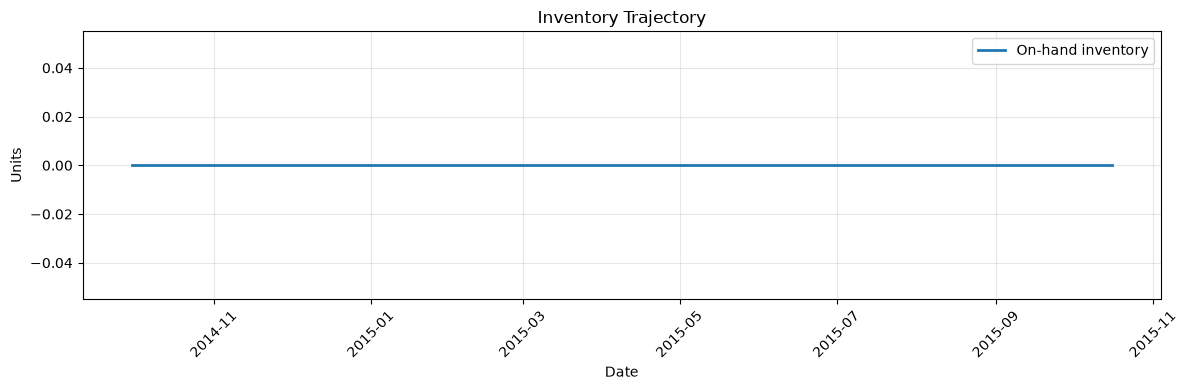

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snapshots["date"], snapshots["on_hand_inventory"], label="On-hand inventory", linewidth=2)
ax.set_title("Inventory Trajectory")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

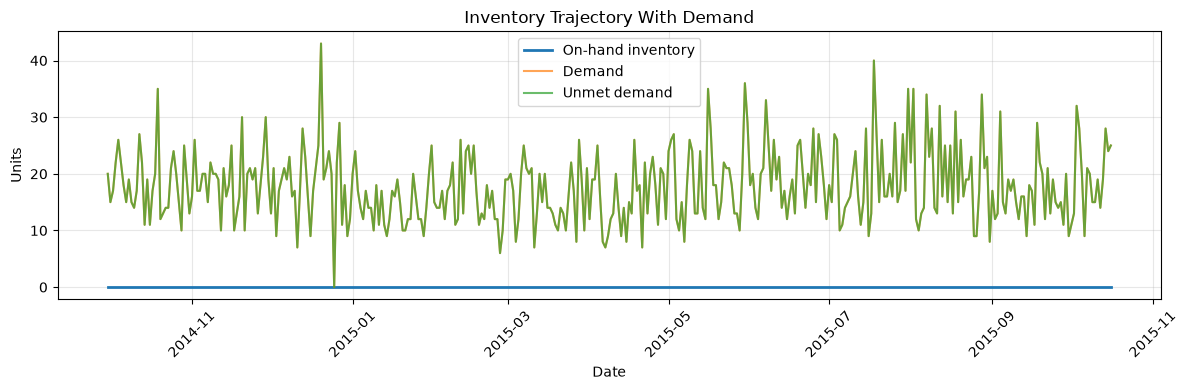

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snapshots["date"], snapshots["on_hand_inventory"], label="On-hand inventory", linewidth=2)
ax.plot(snapshots["date"], snapshots["demand"], label="Demand", alpha=0.7)
ax.plot(snapshots["date"], snapshots["unmet_demand"], label="Unmet demand", alpha=0.7)
ax.set_title("Inventory Trajectory With Demand")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()